# Библиотеки

In [ ]:
!pip install -q langchain_openai==0.0.2 faiss-cpu==1.8.0 openai==1.6.1 tiktoken==0.5.2 langchain_community==0.0.11 langchain==0.1.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.0/27.0 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.4/225.4 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.0/798.0 kB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.2/241.2 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.4/55.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-text-splitters 0.3.0 requires langchain-core<0.4.0,>=0.3.0, but you have langchain-core 0.1.23 which is i

In [ ]:
# импортируем необходимые библиотеки
from openai import OpenAI
from langchain_openai import OpenAIEmbeddings
from langchain.text_splitter import RecursiveCharacterTextSplitter, MarkdownHeaderTextSplitter
from langchain.vectorstores import FAISS
from langchain.docstore.document import Document
import os
import re
import requests
import openai
import tiktoken
import matplotlib.pyplot as plt
from textwrap import fill

import logging
logging.getLogger("langchain.text_splitter").setLevel(logging.ERROR)

In [ ]:
# использование секретного ключа в колабе
from google.colab import userdata
# Получение API ключа из пользовательских данных Colab и установка его как переменной среды
key = userdata.get('open_ai_key_lessons')
os.environ["OPENAI_API_KEY"] = key

# Создание клиента OpenAI с использованием API ключа из переменных среды
client = OpenAI()

# База данных

In [ ]:
# функция для загрузки документа по ссылке из гугл драйв
def load_document_text(url: str) -> str:
    # Extract the document ID from the URL
    match_ = re.search('/document/d/([a-zA-Z0-9-_]+)', url)
    if match_ is None:
        raise ValueError('Invalid Google Docs URL')
    doc_id = match_.group(1)

    # Download the document as plain text
    response = requests.get(f'https://docs.google.com/document/d/{doc_id}/export?format=txt')
    response.raise_for_status()
    text = response.text

    return text

In [ ]:
# База знаний, которая будет подаваться в langChain
database= load_document_text('https://docs.google.com/document/d/1iX1ovb3WZtkTk768M2enZfkLZk2qlK1J/edit?usp=drive_link&ouid=110261677843800451060&rtpof=true&sd=true')            # заполните необходимым значением

In [ ]:
database[:1000]

'\ufeff*О нас*\r\nАтоми – это глобальный интернет-магазин, в котором каждая семья может найти огромное количество товаров для постоянного использования и пополнять свой ассортимент новой уникальной продукцией.\r\nМесто рождения компании - Южная Корея, основана 1 июня 2009 года. Атоми – молодая компания прямых продаж, впервые в мире применившая концепцию «абсолютное качество по абсолютной цене». Это значит, что товары премиум-класса теперь можно приобрести по самым доступным ценам.\r\nБлагодаря данной концепции годовой товарооборот Атоми из года в год стремительно растет и за 2021 год составил более 2 миллиарда долларов США, а количество участников по всему миру превысило 16 миллионов человек. Атом вошла в топ-10 первых компаний прямых продаж. Это отличный показатель стабильного роста и эффективной стратегии развития.\r\nОдним из важных преимуществ Атоми является грамотное открытие международных рынков. Atomy официально сегодня представлена в США, Японии, Канаде, Тайване, Сингапуре, Кам

In [ ]:
# Функция для предобработки текста, оставляющая только обработку жирного текста
def text_to_markdown(text):
    # Функция заменяет текст, выделенный жирным шрифтом (текст между *)
    # и дублирует его строчкой ниже
    def replace_header1(match):
        return f"# {match.group(1)}\n{match.group(1)}"

    # Ищем текст, заключенный в *, и обрабатываем его с помощью replace_header2
    text = re.sub(r'\*([^\*]+)\*', replace_header1, text)

    return text


In [ ]:
markdown = text_to_markdown(database)                 # заполните необходимым значением
print(markdown[:5000])

﻿# О нас
О нас
Атоми – это глобальный интернет-магазин, в котором каждая семья может найти огромное количество товаров для постоянного использования и пополнять свой ассортимент новой уникальной продукцией.
Место рождения компании - Южная Корея, основана 1 июня 2009 года. Атоми – молодая компания прямых продаж, впервые в мире применившая концепцию «абсолютное качество по абсолютной цене». Это значит, что товары премиум-класса теперь можно приобрести по самым доступным ценам.
Благодаря данной концепции годовой товарооборот Атоми из года в год стремительно растет и за 2021 год составил более 2 миллиарда долларов США, а количество участников по всему миру превысило 16 миллионов человек. Атом вошла в топ-10 первых компаний прямых продаж. Это отличный показатель стабильного роста и эффективной стратегии развития.
Одним из важных преимуществ Атоми является грамотное открытие международных рынков. Atomy официально сегодня представлена в США, Японии, Канаде, Тайване, Сингапуре, Камбодже, Филип

# Промпт

In [ ]:
# Инструкция в system
system = '''Ты превосходный нейро-консультант в компании Атоми. У тебя отлично получается консультировать по предоставленному тебе документу.
Дай полный и краткий ответ по предоставленному тебе документу. При ответе не упоминай документ и не добавляй ничего от себя.
Пожалуйста, будь вежливой и работай эффективно.'''


In [ ]:
def num_tokens_from_string(string: str, encoding_name: str) -> int:
      """Возвращает количество токенов в строке"""
      encoding = tiktoken.get_encoding(encoding_name)
      num_tokens = len(encoding.encode(string))
      return num_tokens

def split_text(text, max_count):
    headers_to_split_on = [
        ("#", "Header 1"),
        ("##", "Header 2"),
        ("###", "Header 3"),
    ]

    markdown_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on)
    fragments = markdown_splitter.split_text(text)

    # Подсчет токенов для каждого фрагмента и построение графика
    fragment_token_counts = [num_tokens_from_string(fragment.page_content, "cl100k_base") for fragment in fragments]
    plt.hist(fragment_token_counts, bins=20, alpha=0.5, label='Fragments')
    plt.title('Distribution of Fragment Token Counts')
    plt.xlabel('Token Count')
    plt.ylabel('Frequency')
    plt.show()

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=max_count,
        chunk_overlap=0,
        length_function=lambda x: num_tokens_from_string(x, "cl100k_base")
    )

    source_chunks = [
        Document(page_content=chunk, metadata=fragment.metadata)
        for fragment in fragments
        for chunk in splitter.split_text(fragment.page_content)
    ]

    # Подсчет токенов для каждого source_chunk и построение графика
    source_chunk_token_counts = [num_tokens_from_string(chunk.page_content, "cl100k_base") for chunk in source_chunks]
    plt.hist(source_chunk_token_counts, bins=20, alpha=0.5, label='Source Chunks')
    plt.title('Distribution of Source Chunk Token Counts')
    plt.xlabel('Token Count')
    plt.ylabel('Frequency')
    plt.show()

    return source_chunks

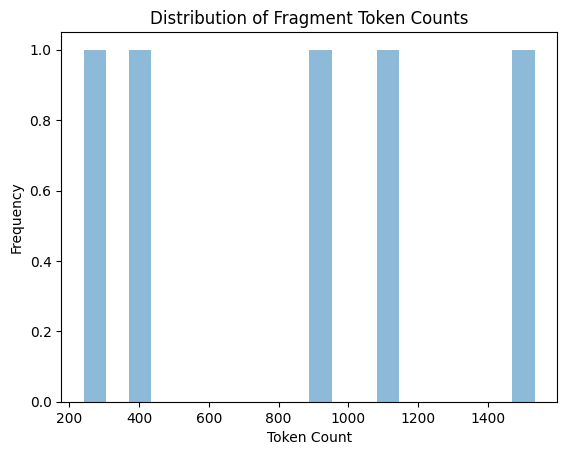

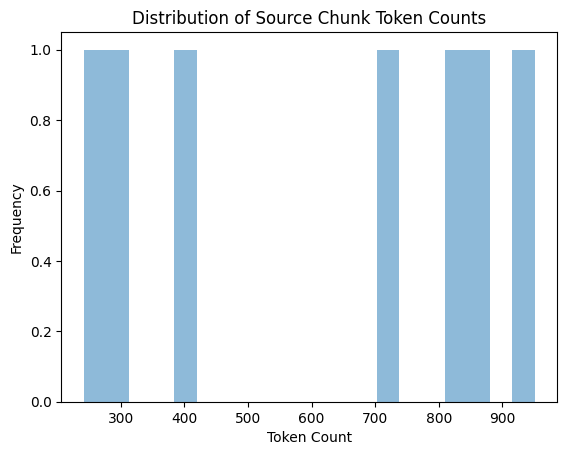

Общее количество чанков:  7
Первый чанк  page_content='\ufeff# О нас\nО нас\nАтоми – это глобальный интернет-магазин, в котором каждая семья может найти огромное количество товаров для постоянного использования и пополнять свой ассортимент новой уникальной продукцией.\nМесто рождения компании - Южная Корея, основана 1 июня 2009 года. Атоми – молодая компания прямых продаж, впервые в мире применившая концепцию «абсолютное качество по абсолютной цене». Это значит, что товары премиум-класса теперь можно приобрести по самым доступным ценам.\nБлагодаря данной концепции годовой товарооборот Атоми из года в год стремительно растет и за 2021 год составил более 2 миллиарда долларов США, а количество участников по всему миру превысило 16 миллионов человек. Атом вошла в топ-10 первых компаний прямых продаж. Это отличный показатель стабильного роста и эффективной стратегии развития.\nОдним из важных преимуществ Атоми является грамотное открытие международных рынков. Atomy официально сегодня предст

In [ ]:
source_chunks = split_text(markdown, 1000)                          # заполните необходимыми значениями
print("Общее количество чанков: ",len(source_chunks))
print("Первый чанк ", source_chunks[0])

# Эмбеддинг

In [ ]:
# Инициализирум модель эмбеддингов
embeddings = OpenAIEmbeddings()

# Создадим индексную базу из разделенных фрагментов текста
db = FAISS.from_documents(source_chunks, embeddings)                            # заполните необходимыми значениями

In [ ]:
def insert_newlines(text: str, max_len: int = 170) -> str:
    """
    Функция разбивает длинный текст на строки определенной максимальной длины.
    """
    words = text.split()
    lines = []
    current_line = ""
    for word in words:
        if len(current_line + " " + word) > max_len:
            lines.append(current_line)
            current_line = ""
        current_line += " " + word
    lines.append(current_line)
    return "\n".join(lines)

# Функция

In [ ]:
def answer_index(system, search_query, topic, search_index, verbose=1):
    # Поиск релевантных отрезков из базы знаний по вопросу пользователя
    docs = search_index.similarity_search(search_query, k=4)
    if verbose:
        print('\n ===========================================: ')

    message_content = re.sub(r'\n{2}', ' ', '\n '.join([f'\n=====================Отрывок документа №{i+1}\n' + doc.page_content + '\n' for i, doc in enumerate(docs)]))
    if verbose:
        print('message_content :\n ======================================== \n', message_content)

    messages = [
        {"role": "system", "content": system},
        {"role": "user", "content": f"Ответь на вопрос пользователя. Документы с информацией для ответа клиенту: {message_content}\n\n{topic}"}
    ]

    if verbose:
        print('\n ===========================================: ')

    completion = client.chat.completions.create(
        model="gpt-4o-mini",                                      # заполните необходимыми значениями
        messages=messages,
        temperature=0.25                                   # заполните необходимыми значениями
        )
    answer = completion.choices[0].message.content
    return answer


In [ ]:
def summarize_questions(dialog):
    """
    Функция возвращает саммаризированный текст диалога.
    """
    messages = [
        {"role": "system", "content": "Ты - нейро-саммаризатор. Твоя задача - саммаризировать диалог, который тебе пришел. Если пользователь назвал свое имя, обязательно отрази его в саммаризированном диалоге"},
        {"role": "user", "content": "Саммаризируй следующий диалог консультанта и пользователя: " + " ".join(dialog)}
    ]

    completion = client.chat.completions.create(
        model="gpt-4o-mini",      # заполните необходимыми значениями
        messages=messages,
        temperature=0          # Используем более низкую температуру для более определенной суммаризации
    )

    return completion.choices[0].message.content

In [ ]:
def answer_user_question_dialog(system, db, user_question, question_history):
    """
    Функция возвращает ответ на вопрос пользователя.
    """
    summarized_history = ""
    # Если в истории более одного вопроса, применяем суммаризацию
    if len(question_history) > 0:
        summarized_history = "Вот саммаризированный предыдущий диалог с пользователем: " +summarize_questions([q + ' ' + (a if a else '') for q, a in question_history])

    topic = summarized_history + " Актуальный вопрос пользователя: " + user_question

    # Получаем ответ, используя только user_question для поиска в базе данных
    answer_text = answer_index(system, user_question, topic, db)

    question_history.append((user_question, answer_text if answer_text else ''))
    # Выводим саммаризированный текст, который видит модель
    if summarized_history:
        print('****************************')
        print(summarized_history)
        print('****************************')

    return answer_text


In [ ]:
def run_dialog(system_doc_url, knowledge_base_url):
    """
    Функция запускает диалог между пользователем и нейро-консультантом.
    """
    #список кортежей, где каждый кортеж содержит пару вопрос-ответ, для отслеживания истории вопросов и ответов во время сессии диалога.
    question_history = []
    while True:
        user_question = input('Пользователь: ')
        if user_question.lower() == 'stop':
            break
        answer = answer_user_question_dialog(system_doc_url, knowledge_base_url, user_question, question_history)
        print('Консультант:', insert_newlines(answer))

    return

# Тест

In [ ]:
# проверьте работу нейро-консультанта на нескольких самостоятельно сгенерированных вопросах. Проверьте, что соблюдаются инструкции и поддерживается диалог
run_dialog(system, db)

Пользователь: Привет

 ===========================================: 
message_content :
 
=====================Отрывок документа №1
Создание Atomy. Все началось в старом, видавшем виды уютном ресторанчике в городе Иксане провинции Северная Чолла. На старой подержанно машине, которая в любой момент могла развалится, я приехал, чтобы объяснить свою идею компании примерно 17-18 людям, переживавшим трудные времена. Сейчас, оглядываясь назад, я понимаю, что все это выглядело странно, но именно так началась история компании. Никто не хотел вкладывать деньги в молодую компанию сетевого маркетинга. Было трудно нанять людей даже в качестве продавцов. В том старом маленьком ресторанчике я сказал этим людям, что однажды они смогут жить в лучших домах Иксана. Я также сказал им, что, если они достигнут ранга «Имериал мастер», я выдам им 1 миллиард корейских вон наличными. Большинство из них, вероятно, подумали, что я просто мечтатель. Тем не менее, первые участники будущей компании ухватились за мои